# Support Vector Machine Project
Welcome to your Support Vector Machine Project! We will be analyzing the famous iris data set!

## The Data

For this series of lectures, we will be using the famous https://en.wikipedia.org/wiki/Iris_flower_data_set

The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by Sir Ronald Fisher in the 1936 as an example of discriminant analysis.<br>

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor), so 150 total samples. Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.<br>

The iris dataset contains measurements for 150 iris flowers from three different species.<br>

The three classes in the Iris dataset:<br>

* Iris-setosa (n=50)
* Iris-versicolor (n=50)
* Iris-virginica (n=50)

The four features of the Iris dataset:

* sepal length in cm
* sepal width in cm
* petal length in cm
* petal width in cm

# Get the data

**Use seaborn to get the iris data by using: iris = sns.load_dataset('iris')**

In [42]:
import seaborn as sns

In [43]:
iris = sns.load_dataset('iris')

Let's visualize the data get you started!

# Exploratory Data Analysis

**Import some libraries you think you'll need.**

In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [14]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Create a pairplot of the data set. Which flower species seems to be the most separable?**

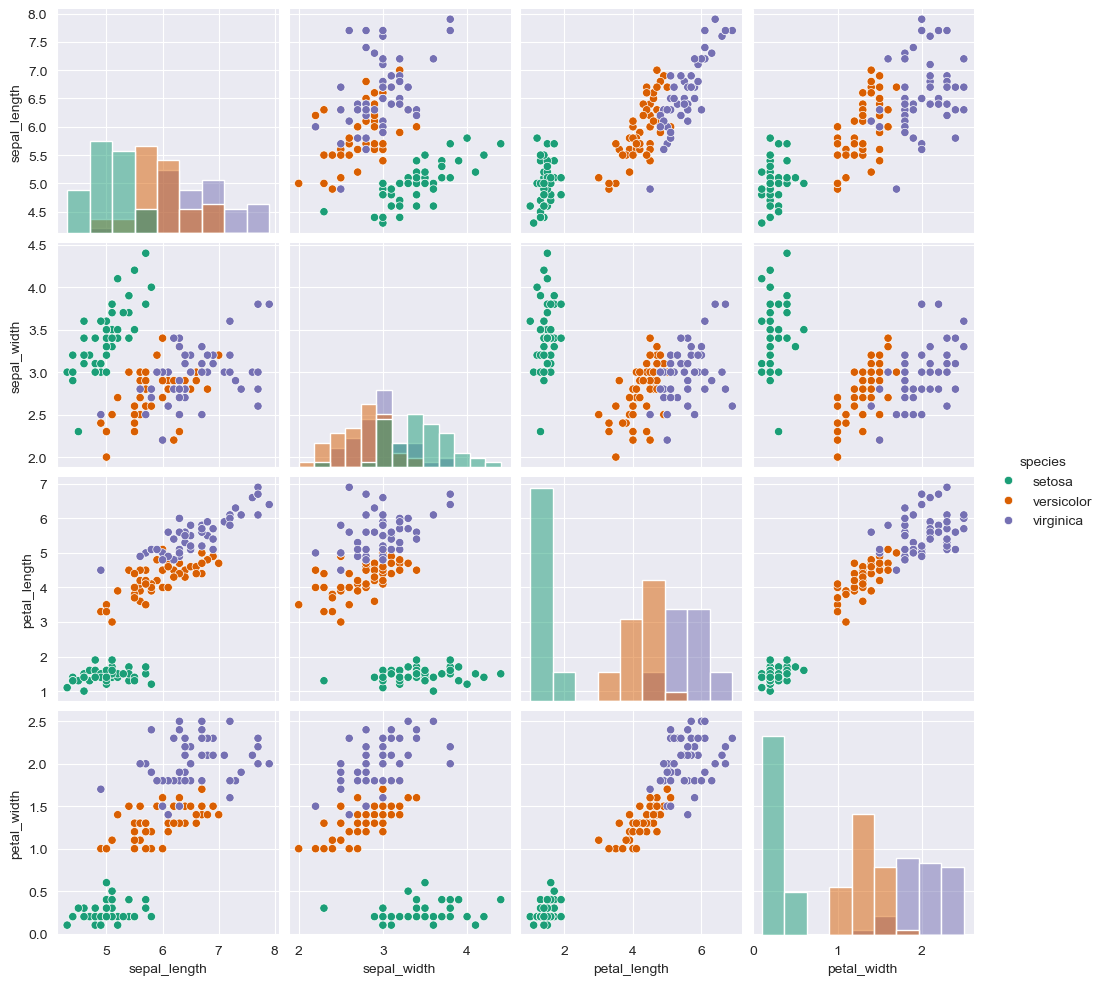

In [ ]:
sns.set_style('darkgrid')
sns.pairplot(iris, hue='species', diag_kind='hist', palette='Dark2')

**Create a kde plot of sepal_length versus sepal_width for setosa species of flower**

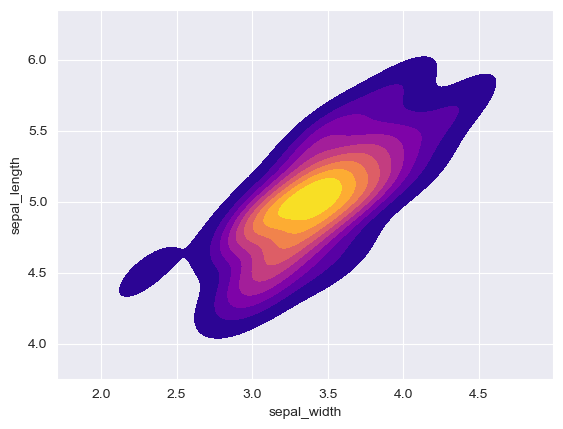

In [ ]:
setosa = iris[iris['species']=='setosa']
sns.kdeplot(x=setosa['sepal_width'], y=setosa['sepal_length'], cmap='plasma', fill=True)

# Train Test Split
**Split your data into a training set and a testing set.**

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = iris.drop('species', axis=1)
y = iris['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train a Model
Now its time to train a Support Vector Machine Classifier.

**Call the SVC() model from sklearn and fit the model to the training data.**

In [25]:
from sklearn.svm import SVC

In [26]:
svc_model = SVC()

In [27]:
svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Model Evaluation
**Now get predictions from the model and create a confusion matrix and a classification report.**

In [28]:
predictions = svc_model.predict(X_test)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
print(confusion_matrix(y_test, predictions))

[[14  0  0]
 [ 0 10  0]
 [ 0  1  5]]


In [33]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.97      0.94      0.95        30
weighted avg       0.97      0.97      0.97        30



# GridSearch Practice
**Import GridSearchCV from Scikit Learn.**

In [35]:
from sklearn.model_selection import GridSearchCV

**Create a dictionary called param_grid and fill out some parameters for C and gamma.**

In [36]:
param_grid = {"C":[0.1,1,10,100], "gamma":[1,0.1,0.01,0.001]}

**Create a GridSearchCV object and fit it to the training data.**

In [37]:
grid = GridSearchCV(SVC(), param_grid, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


**Now take that grid model and create some predictions using the test set and create classification reports and confusion matrices for them. Were you able to improve?**

In [38]:
grid_predictions = grid.predict(X_test)

In [40]:
print(confusion_matrix(y_test, predictions))

[[14  0  0]
 [ 0 10  0]
 [ 0  1  5]]


In [41]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.97      0.94      0.95        30
weighted avg       0.97      0.97      0.97        30



You should have done the same or exactly the same, this makes sense, there is basically just one point that is too noisey to grab, which makes sense, we don't want to have an overfit model that would be able to grab that.

# Well Done!